In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorSampler, StatevectorEstimator as Estimator
from qiskit_algorithms.optimizers import ADAM
from qiskit_machine_learning.algorithms import VQC
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import EstimatorQNN, EffectiveDimension, LocalEffectiveDimension, SamplerQNN

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [2]:
#loading the datset
iris = load_iris()

X = iris.data       
y = iris.target     


# Task 1

## 1.1

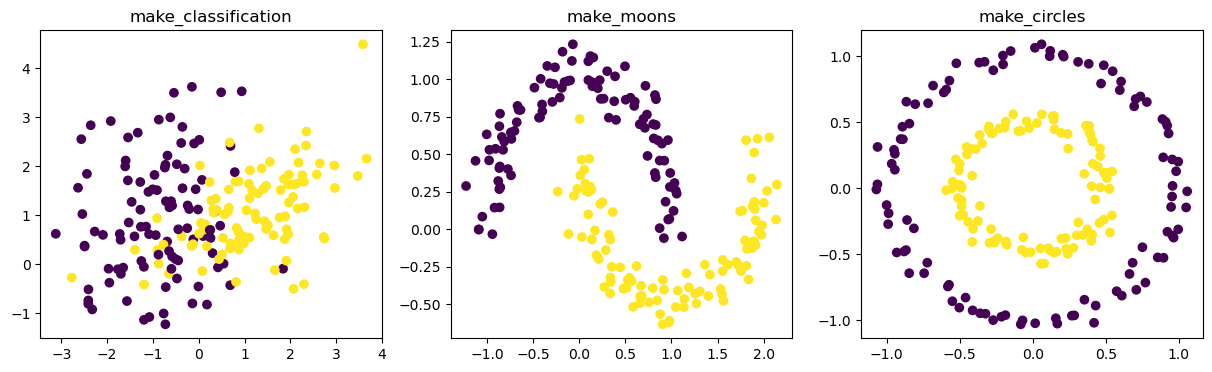

In [6]:
#linear datset
X_class, y_class = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

#moons dataset
X_moons, y_moons = make_moons(
    n_samples=200,
    noise=0.1,
    random_state=42
)

#circles dataset
X_circles, y_circles = make_circles(
    n_samples=200,
    noise=0.05,
    factor=0.5,
    random_state=42
)

#visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(X_class[:,0], X_class[:,1], c=y_class)
axes[0].set_title("make_classification")

axes[1].scatter(X_moons[:,0], X_moons[:,1], c=y_moons)
axes[1].set_title("make_moons")

axes[2].scatter(X_circles[:,0], X_circles[:,1], c=y_circles)
axes[2].set_title("make_circles")

plt.show()

In [7]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


## 1.2

### setosa vs versicolor

In [8]:
#taking two corresponding labels
mask = y < 2

X_set_vers = X[mask]
y_set_vers = y[mask]

In [9]:
#splitting in training and test
X_train_sv, X_test_sv, y_train_sv, y_test_sv = train_test_split(
    X_set_vers,
    y_set_vers,
    test_size=0.2,
    random_state=42
)

In [10]:
#scaling X datset
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train_sv = scaler.fit_transform(X_train_sv)
X_test_sv = scaler.transform(X_test_sv)

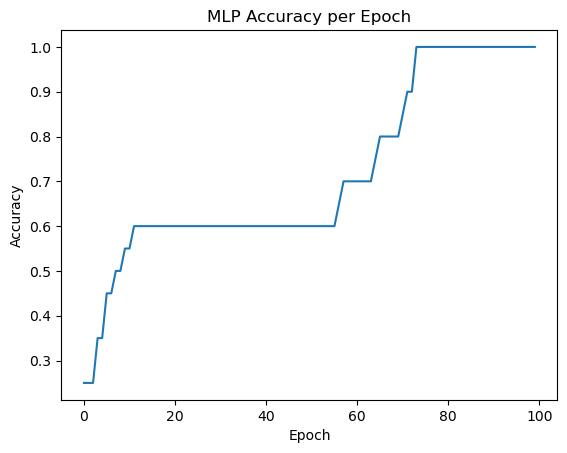

In [11]:
#classical neural network
model = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation='relu',
    solver='adam',
    max_iter=1,   # training step-by-step
    warm_start=True,
    random_state=42
)
epochs = 100
accuracies = []

for i in range(epochs):
    model.fit(X_train_sv, y_train_sv)

    y_pred = model.predict(X_test_sv)
    acc = accuracy_score(y_test_sv, y_pred)

    accuracies.append(acc)
plt.plot(accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Accuracy per Epoch")
plt.show()

### versicolor vs virginica

In [12]:
#taking two corresponding labels
mask = y >= 1

X_set_vevi = X[mask]
y_set_vevi = y[mask]

In [13]:
#splitting in training and test
X_train_vevi, X_test_vevi, y_train_vevi, y_test_vevi = train_test_split(
    X_set_vevi,
    y_set_vevi,
    test_size=0.2,
    random_state=42
)

In [14]:
#scaling X datset
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train_vevi = scaler.fit_transform(X_train_vevi)
X_test_vevi = scaler.transform(X_test_vevi)

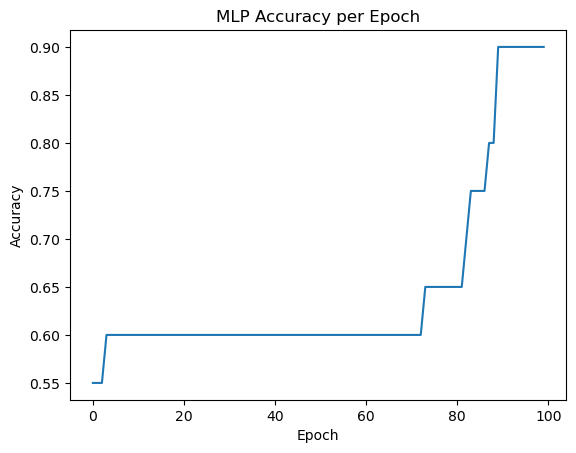

In [15]:
#classical neural network
model = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation='relu',
    solver='adam',
    max_iter=1,   # training step-by-step
    warm_start=True,
    random_state=42
)
epochs = 100
accuracies = []

for i in range(epochs):
    model.fit(X_train_vevi, y_train_vevi)

    y_pred = model.predict(X_test_vevi)
    acc = accuracy_score(y_test_vevi, y_pred)

    accuracies.append(acc)
plt.plot(accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Accuracy per Epoch")
plt.show()

### setosa vs virginica

In [61]:
#taking two corresponding labels
mask = y!= 1

X_set_sevi = X[mask]
y_set_sevi = y[mask]

In [62]:
#splitting in training and test
X_train_sevi, X_test_sevi, y_train_sevi, y_test_sevi = train_test_split(
    X_set_sevi,
    y_set_sevi,
    test_size=0.2,
    random_state=42
)

In [63]:
#scaling X datset
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train_sevi = scaler.fit_transform(X_train_sevi)
X_test_sevi = scaler.transform(X_test_sevi)

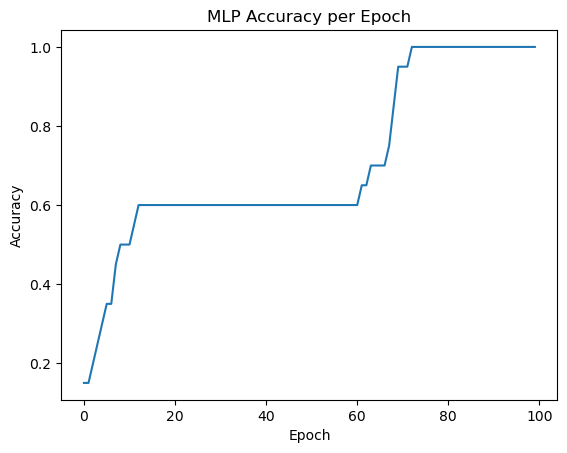

In [64]:
#classical neural network
model = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation='relu',
    solver='adam',
    max_iter=1,   # training step-by-step
    warm_start=True,
    random_state=42
)
epochs = 100
accuracies = []

for i in range(epochs):
    model.fit(X_train_sevi, y_train_sevi)

    y_pred = model.predict(X_test_sevi)
    acc = accuracy_score(y_test_sevi, y_pred)

    accuracies.append(acc)
plt.plot(accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Accuracy per Epoch")
plt.show()

### one vs rest 

In [78]:
#Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [79]:
#Scaling the dataset
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

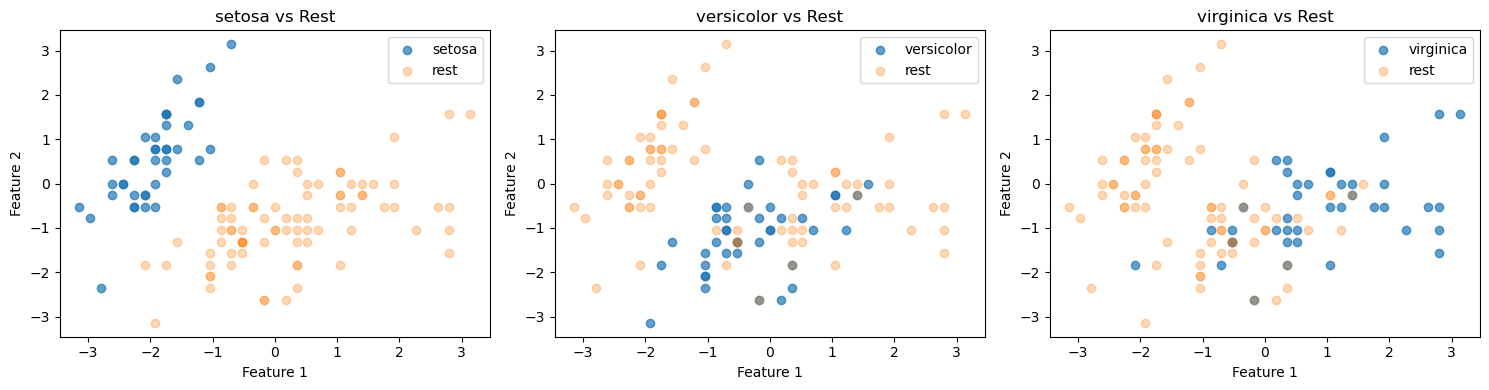

In [80]:
X_vis = X_train[:, :2]

classes = iris.target_names

plt.figure(figsize=(15, 4))

for i, c in enumerate([0, 1, 2]):

    y_bin = (y_train == c)

    plt.subplot(1, 3, i+1)

    plt.scatter(
        X_vis[y_bin, 0],
        X_vis[y_bin, 1],
        label=f"{classes[c]}",
        alpha=0.7
    )

    plt.scatter(
        X_vis[~y_bin, 0],
        X_vis[~y_bin, 1],
        label="rest",
        alpha=0.3
    )

    plt.title(f"{classes[c]} vs Rest")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()

plt.tight_layout()
plt.show()

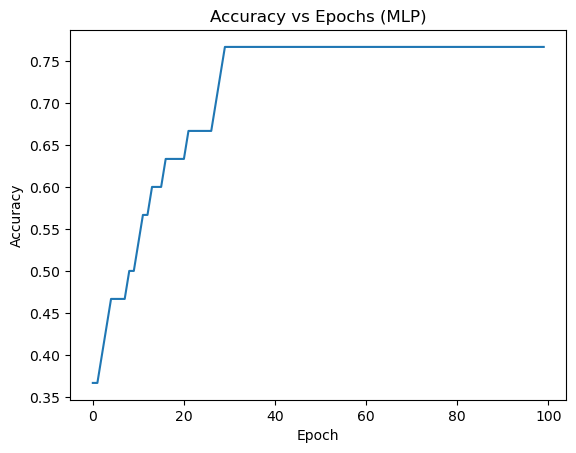

In [81]:
model = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation='relu',
    solver='adam',
    max_iter=1,
    warm_start=True,
    random_state=42
)

epochs = 100
accuracies = []

for epoch in range(epochs):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)

plt.plot(range(epochs), accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs (MLP)")
plt.show()

## 1.4

The dataset is already in 4 dimensions, PCA in 4 dimensions means to just change base 

Having two feautures consents a two qubits quantum network

### e.g setosa vs virgina pca2

In [92]:
#taking two corresponding labels
mask = y!= 1

X_set_sevi = X[mask]
y_set_sevi = y[mask]

In [93]:
#splitting in training and test
X_train_sevi, X_test_sevi, y_train_sevi, y_test_sevi = train_test_split(
    X_set_sevi,
    y_set_sevi,
    test_size=0.2,
    random_state=42
)

In [95]:
#Trasforming the dataset from 4 features to 2 with pca
pca2 = PCA(n_components=2)
X_train_pca2 = pca2.fit_transform(X_train_sevi)
X_test_pca2 = pca2.transform(X_test_sevi)

In [96]:
#scaling X datset
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train_pca2 = scaler.fit_transform(X_train_pca2)
X_test_pca2 = scaler.transform(X_test_pca2)

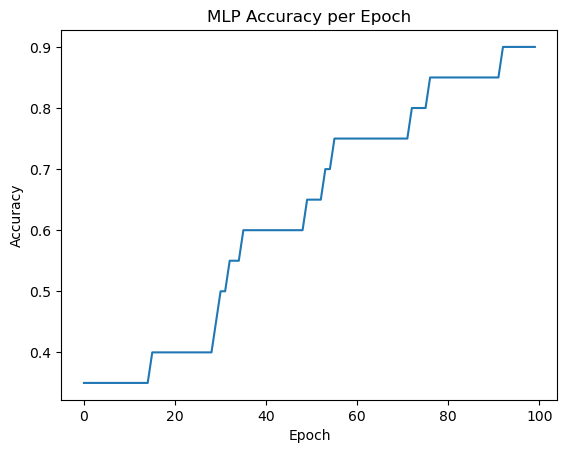

In [98]:
#classical neural network
model = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation='relu',
    solver='adam',
    max_iter=1,   # training step-by-step
    warm_start=True,
    random_state=42
)
epochs = 100
accuracies = []

for i in range(epochs):
    model.fit(X_train_pca2, y_train_sevi)

    y_pred = model.predict(X_test_pca2)
    acc = accuracy_score(y_test_sevi, y_pred)

    accuracies.append(acc)
plt.plot(accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Accuracy per Epoch")
plt.show()

# Task 2

## 2.1 - 2.2 Creating Quantum Circuit

In [3]:
# Function to Build the Quantum Circuit

# -----------------------
# Feature Map without entanglement to provide a classical map into a quantum circuit
# -----------------------
def EasyFeatureMap(N):
    x = ParameterVector('x', N)
    qc = QuantumCircuit(N)        
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    qc.barrier()
    return qc

# -----------------------
# Feature Map
# -----------------------
def FeatureMap(N):
    x = ParameterVector('x', N)
    qc = QuantumCircuit(N)        
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    for i in range(N):
        for j in range(i):
            qc.cx(j, i)
            qc.rz(x[j] * x[i], i)
            qc.cx(j, i)
        qc.barrier()
    return qc

# -----------------------
# Variational Model
# -----------------------
def Ansatz(N):
    theta = ParameterVector('theta', 2*N)
    qc = QuantumCircuit(N)
    for i in range(N):
        qc.ry(theta[i], i)
    qc.barrier()
    for i in range(N-1):
        for j in range(i+1,N):
            qc.cx(i, j)
    qc.barrier()
    for i in range(N):
        qc.ry(theta[i+N], i)
    return qc

#-----------------------
# Parity Interpreter
# ----------------------
def parity(x):
    return "{:b}".format(x).count("1") % 2


In [4]:
#taking two corresponding labels
mask = y < 2

X_set = X[mask]
y_set = y[mask]
scaler   = MinMaxScaler(feature_range=(-np.pi, np.pi))        
x_scaled = scaler.fit_transform(X_set)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y_set, test_size=0.2, random_state=42, stratify=y_set
)

N = 4
# Creating the Circuits' parts
easy_feature_map = EasyFeatureMap(N)
feature_map = FeatureMap(N)
ansatz      = Ansatz(N)

### QNN

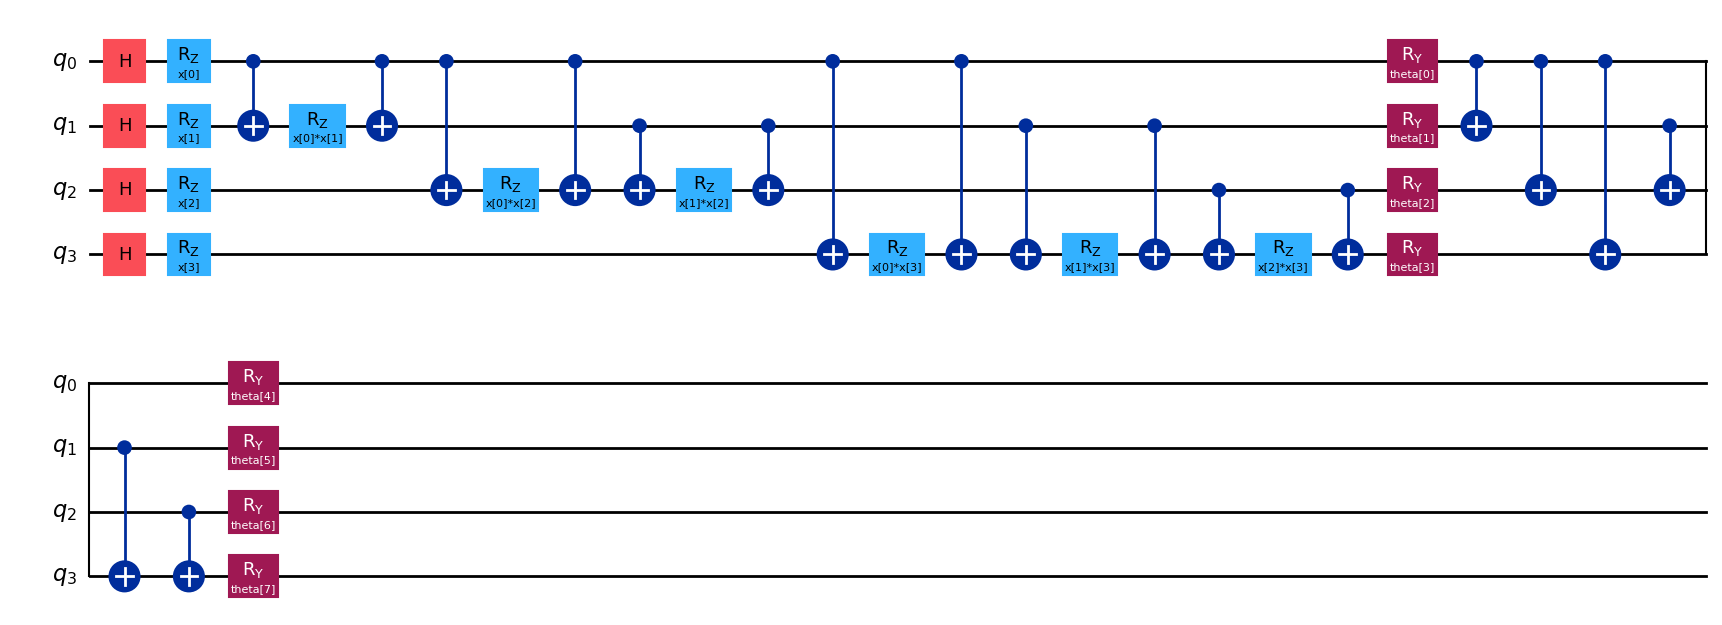

In [5]:
qc = feature_map.copy().compose(ansatz.copy())
qc.draw("mpl", style="iqp", plot_barriers=False)

### easy QNN

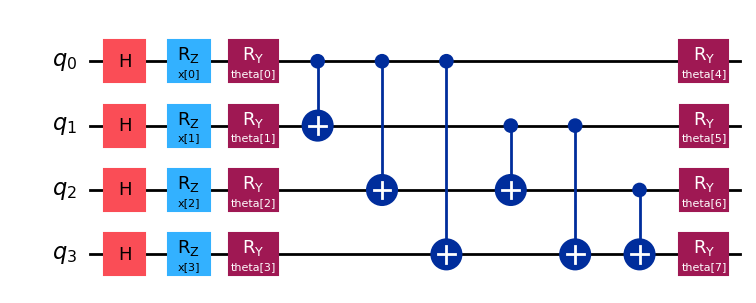

In [6]:
easy_qc = easy_feature_map.copy().compose(ansatz.copy())
easy_qc.draw("mpl", style="iqp", plot_barriers=False)

## 2.2 - SamplerQNN

In [50]:
# ── SamplerQNN factory ───────────────────────────────────────────────────
def make_sampler_qnn(feature_map_fn, ansatz_fn, N):
    circ    = feature_map_fn(N).compose(ansatz_fn(N))
    x_p     = sorted([p for p in circ.parameters if p.name.startswith('x')],
                      key=lambda p: p.index)
    theta_p = sorted([p for p in circ.parameters if p.name.startswith('theta')],
                      key=lambda p: p.index)
    return SamplerQNN(
        circuit=circ,
        input_params=x_p,
        weight_params=theta_p,
        interpret=parity,
        output_shape=2,
        sampler=StatevectorSampler(),
    )

qnn_s      = make_sampler_qnn(FeatureMap,     Ansatz, N)
qnn_s_easy = make_sampler_qnn(EasyFeatureMap, Ansatz, N)

d = qnn_s.num_weights   # number of trainable parameters = 2*N
print(f'num_inputs : {qnn_s.num_inputs}')
print(f'num_weights: {d}')


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


num_inputs : 4
num_weights: 8


## 2.3 - Effective Dimension

In [51]:
from qiskit_machine_learning.utils import algorithm_globals
algorithm_globals.random_seed = 42

# Dataset sizes to evaluate ED over (as in the official tutorial)
n = [5000, 8000, 10000, 40000, 60000, 100000, 150000, 200000, 500000, 1000000]

# ══════════════════════════════════════════════════════════════════════
# 1. GLOBAL EFFECTIVE DIMENSION
#    - Many random weight sets → measures overall model capacity
#    - Higher ED/d → more expressive model
# ══════════════════════════════════════════════════════════════════════
global_ed_qnn  = EffectiveDimension(qnn=qnn_s,      weight_samples=50, input_samples=50)
global_ed_easy = EffectiveDimension(qnn=qnn_s_easy, weight_samples=50, input_samples=50)

global_eff_qnn  = global_ed_qnn.get_effective_dimension(dataset_size=n)
global_eff_easy = global_ed_easy.get_effective_dimension(dataset_size=n)

print(f'Global ED QNN  (n=5000): {global_eff_qnn[0]:.4f}  normalized: {global_eff_qnn[0]/d:.4f}')
print(f'Global ED easy (n=5000): {global_eff_easy[0]:.4f}  normalized: {global_eff_easy[0]/d:.4f}')

# ══════════════════════════════════════════════════════════════════════
# 2. LOCAL EFFECTIVE DIMENSION
#    - Single weight set → measures expressiveness of a specific parameterization
#    - Compare random (untrained) vs trained weights
#    - Expected: ED decreases after training (implicit regularization)
# ══════════════════════════════════════════════════════════════════════

# Random untrained weights (reproducible via algorithm_globals seed)
untrained_weights = algorithm_globals.random.uniform(0, 2 * np.pi, d)

# Trained weights: run a quick VQC fit to get a trained weight set
def get_trained_weights(feature_map_fn, ansatz_fn, N, x_tr, y_tr, maxiter=100):
    trained_weights_store = []
    def adam_capture(fun, x0, jac=None, **kwargs):
        opt = ADAM(maxiter=maxiter, lr=0.1, beta_1=0.9, beta_2=0.99, tol=1e-8)
        def tracked_jac(w):
            trained_weights_store.append(w.copy())
            return jac(w)
        return opt.minimize(fun=fun, x0=x0, jac=tracked_jac)
    vqc = VQC(
        sampler=StatevectorSampler(),
        feature_map=feature_map_fn(N),
        ansatz=ansatz_fn(N),
        optimizer=adam_capture,
    )
    vqc.fit(x_tr, y_tr)
    return trained_weights_store[-1] if trained_weights_store else vqc.weights

print('Training QNN for local ED...')
trained_weights_qnn  = get_trained_weights(FeatureMap,     Ansatz, N, x_train, y_train)
print('Training easy QNN for local ED...')
trained_weights_easy = get_trained_weights(EasyFeatureMap, Ansatz, N, x_train, y_train)

# Local ED — QNN
local_ed_trained_qnn   = LocalEffectiveDimension(qnn=qnn_s,      weight_samples=trained_weights_qnn,  input_samples=x_train)
local_ed_untrained_qnn = LocalEffectiveDimension(qnn=qnn_s,      weight_samples=untrained_weights,    input_samples=x_train)
# Local ED — easy QNN
local_ed_trained_easy   = LocalEffectiveDimension(qnn=qnn_s_easy, weight_samples=trained_weights_easy, input_samples=x_train)
local_ed_untrained_easy = LocalEffectiveDimension(qnn=qnn_s_easy, weight_samples=untrained_weights,    input_samples=x_train)

local_eff_trained_qnn    = local_ed_trained_qnn.get_effective_dimension(dataset_size=n)
local_eff_untrained_qnn  = local_ed_untrained_qnn.get_effective_dimension(dataset_size=n)
local_eff_trained_easy   = local_ed_trained_easy.get_effective_dimension(dataset_size=n)
local_eff_untrained_easy = local_ed_untrained_easy.get_effective_dimension(dataset_size=n)

# ══════════════════════════════════════════════════════════════════════
# 3. FISHER INFORMATION MATRIX
#    - Extracted from run_monte_carlo() — same call used internally by ED
#    - Trace: global sensitivity to parameters (low → barren plateau)
#    - Eigenvalues: distribution of sensitivity across parameter directions
# ══════════════════════════════════════════════════════════════════════
def compute_fim(ed_obj):
    """Run MC once, return FIM averaged over input samples. Shape: (n_weights, n_weights)"""
    grads, outputs = ed_obj.run_monte_carlo()
    fim = ed_obj.get_fisher_information(grads, outputs)  # (n_samples, n_w, n_w)
    return fim.mean(axis=0)                               # (n_w, n_w)

fim_trained_qnn    = compute_fim(local_ed_trained_qnn)
fim_untrained_qnn  = compute_fim(local_ed_untrained_qnn)
fim_trained_easy   = compute_fim(local_ed_trained_easy)
fim_untrained_easy = compute_fim(local_ed_untrained_easy)

print(f'FIM trace QNN   trained: {np.trace(fim_trained_qnn):.4f}')
print(f'FIM trace QNN untrained: {np.trace(fim_untrained_qnn):.4f}')
print(f'FIM trace easy   trained: {np.trace(fim_trained_easy):.4f}')
print(f'FIM trace easy untrained: {np.trace(fim_untrained_easy):.4f}')

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Global ED QNN  (n=5000): 7.0630  normalized: 0.8829
Global ED easy (n=5000): 5.7603  normalized: 0.7200
Training QNN for local ED...


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Training easy QNN for local ED...
FIM trace QNN   trained: 0.4656
FIM trace QNN untrained: 0.3448
FIM trace easy   trained: 0.2288
FIM trace easy untrained: 0.2965


In [1]:
# ══════════════════════════════════════════════════════════════════════
# 4. PLOTS
# ══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ── Row 1: Effective Dimension ────────────────────────────────
# Global ED
axes[0,0].plot(n, np.array(global_eff_qnn)  / d, marker='o', color='blue',        label='QNN')
axes[0,0].plot(n, np.array(global_eff_easy) / d, marker='s', color='forestgreen', label='easy QNN')
axes[0,0].set_xscale('log')
axes[0,0].set_ylim([0, 1])
axes[0,0].set_xlabel('Number of data samples (n)')
axes[0,0].set_ylabel('Normalized Global ED')
axes[0,0].set_title('Global Effective Dimension')
axes[0,0].legend()
axes[0,0].grid(True)

# Local ED — QNN
axes[0,1].plot(n, np.array(local_eff_trained_qnn)   / d, color='blue', marker='o', label='trained')
axes[0,1].plot(n, np.array(local_eff_untrained_qnn) / d, color='blue', marker='o', label='untrained', linestyle='--')

axes[0,1].plot(n, np.array(local_eff_trained_easy)   / d, color='forestgreen', marker='s', label='trained')
axes[0,1].plot(n, np.array(local_eff_untrained_easy) / d, color='forestgreen', marker='s', label='untrained', linestyle='--')

axes[0,1].set_xscale('log')
axes[0,1].set_ylim([0, 1])
axes[0,1].set_xlabel('Number of data samples (n)')
axes[0,1].set_ylabel('Normalized Local ED')
axes[0,1].set_title('Local ED — QNN vs easy QNN')
axes[0,1].legend()
axes[0,1].grid(True)

# Local ED — easy QNN
axes[0,2].off()

# ── Row 2: Fisher Information ─────────────────────────────────
# FIM heatmap — QNN trained
im0 = axes[1,0].imshow(fim_trained_qnn, cmap='viridis')
axes[1,0].set_title('FIM — QNN trained')
axes[1,0].set_xlabel('Parameter index')
axes[1,0].set_ylabel('Parameter index')
plt.colorbar(im0, ax=axes[1,0])

# FIM heatmap — easy QNN trained
im1 = axes[1,1].imshow(fim_trained_easy, cmap='viridis')
axes[1,1].set_title('FIM — easy QNN trained')
axes[1,1].set_xlabel('Parameter index')
axes[1,1].set_ylabel('Parameter index')
plt.colorbar(im1, ax=axes[1,1])

# Eigenvalue spectrum: trained vs untrained for both models
eig_trained_qnn    = np.sort(np.linalg.eigvalsh(fim_trained_qnn))[::-1]
eig_untrained_qnn  = np.sort(np.linalg.eigvalsh(fim_untrained_qnn))[::-1]
eig_trained_easy   = np.sort(np.linalg.eigvalsh(fim_trained_easy))[::-1]
eig_untrained_easy = np.sort(np.linalg.eigvalsh(fim_untrained_easy))[::-1]

x_idx = range(1, d + 1)
axes[1,2].semilogy(x_idx, eig_trained_qnn,    'o-',  color='blue',        label='QNN trained')
axes[1,2].semilogy(x_idx, eig_untrained_qnn,  'o--', color='blue',        label='QNN untrained', alpha=0.5)
axes[1,2].semilogy(x_idx, eig_trained_easy,   's-',  color='forestgreen', label='easy trained')
axes[1,2].semilogy(x_idx, eig_untrained_easy, 's--', color='forestgreen', label='easy untrained', alpha=0.5)
axes[1,2].set_xlabel('Eigenvalue index')
axes[1,2].set_ylabel('Eigenvalue (log scale)')
axes[1,2].set_title('FIM Eigenvalue Spectrum')
axes[1,2].legend(fontsize=8)
axes[1,2].grid(True)

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

The QNN is better than the easy QNN

# Task 3

# Task 4

# Task 5

# Task 6

# Task 7